In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from scipy.spatial.distance import cdist


In [2]:
def gaussian_kernel(X, Y, sigma):
    """Gaussian kernel: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = X_sq + Y_sq - 2 * X @ Y.T
    return np.exp(-dist_sq / (2 * sigma ** 2))

def auto_select_sigma(X, multiplier=5):
    """sigma = multiplier * mean(nearest-neighbor distances)."""
    D = cdist(X, X, metric='euclidean')
    np.fill_diagonal(D, np.inf)
    d_nn = np.min(D, axis=1)
    return multiplier * np.mean(d_nn)

def pca_classify(X_train, y_train, X_test, y_test, k):
    """PCA + 1-NN classification. Returns accuracy (%)."""
    mf = np.mean(X_train, axis=0)
    X_tr_c = X_train - mf
    X_te_c = X_test - mf
    n = X_tr_c.shape[0]
    cov_small = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, evecs_small = np.linalg.eigh(cov_small)
    idx = np.argsort(evals)[::-1]
    evecs_small = evecs_small[:, idx]
    evecs = X_tr_c.T @ evecs_small
    evecs = evecs / np.linalg.norm(evecs, axis=0)
    W = evecs[:, :k]
    dists = cdist(X_te_c @ W, X_tr_c @ W, metric='euclidean')
    preds = y_train[np.argmin(dists, axis=1)]
    return np.mean(preds == y_test) * 100

def kpca_classify(X_train, y_train, X_test, y_test, k, sigma):
    """KPCA + 1-NN classification. Returns accuracy (%)."""
    K_tr = gaussian_kernel(X_train, X_train, sigma)
    N = K_tr.shape[0]
    one_N = np.ones((N, N)) / N
    K_c = K_tr - one_N @ K_tr - K_tr @ one_N + one_N @ K_tr @ one_N

    ev, evec = np.linalg.eigh(K_c)
    idx = np.argsort(ev)[::-1]
    ev = ev[idx]; evec = evec[:, idx]
    pos = ev > 1e-10
    ev = ev[pos]; evec = evec[:, pos]
    al = evec / np.sqrt(ev)
    Xtr_p = K_c @ al

    K_te = gaussian_kernel(X_test, X_train, sigma)
    N_te = X_test.shape[0]
    one_te = np.ones((N_te, N)) / N
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    Xte_p = K_te_c @ al

    k = min(k, Xtr_p.shape[1])
    dists = cdist(Xte_p[:, :k], Xtr_p[:, :k], metric='euclidean')
    preds = y_train[np.argmin(dists, axis=1)]
    return np.mean(preds == y_test) * 100


### PCA vs KPCA on Yale Faces

We first compare PCA and KPCA on the Yale Faces dataset, which contains 15 subjects with 11 images each. This serves as a baseline before moving to the larger Extended Yale B dataset.

In [3]:
# Load the small Yale Faces dataset

def load_yale_faces(path):
    persons = {}
    for folder in sorted(os.listdir(path)):
        fp = os.path.join(path, folder)
        if os.path.isdir(fp):
            imgs = []
            for f in sorted(os.listdir(fp)):
                ffp = os.path.join(fp, f)
                if os.path.isfile(ffp):
                    try:
                        imgs.append(np.array(Image.open(ffp), dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_yale(persons, n_train, seed=42):
    import random
    random.seed(seed)
    tr_i, tr_l, te_i, te_l = [], [], [], []
    for label, imgs in persons.items():
        idx = list(range(len(imgs)))
        random.shuffle(idx)
        for i in idx[:n_train]:
            tr_i.append(imgs[i]); tr_l.append(label)
        te_i.append(imgs[random.choice(idx[n_train:])])
        te_l.append(label)
    return (np.array([i.flatten() for i in tr_i]), np.array(tr_l),
            np.array([i.flatten() for i in te_i]), np.array(te_l))

persons_yale = load_yale_faces("Datasets/yalefaces")
print(f"Yale Faces: {len(persons_yale)} subjects, {len(next(iter(persons_yale.values())))} images each")
print(f"Image size: {next(iter(persons_yale.values()))[0].shape}")


Yale Faces: 15 subjects, 11 images each
Image size: (243, 320)


In [ ]:
# ── Yale Faces (n_train=5): KPCA accuracy vs number of components ──────────────
# Auto-sigma uses the 5x rule (training set only -> no test leakage), the same
# setting used for Extended Yale B below.
X_tr, y_tr, X_te, y_te = split_yale(persons_yale, n_train=5)
sigma_yale = auto_select_sigma(X_tr, multiplier=5)
print(f"n_train=5  ->  auto sigma (5x) = {sigma_yale:.0f}")

def kpca_fit_project(X_train, X_test, sigma):
    """Return KPCA projections (Ztr, Zte) using a centered Gram matrix and
    out-of-sample centering with the training kernel statistics."""
    K_tr = gaussian_kernel(X_train, X_train, sigma); N = K_tr.shape[0]
    one_N = np.ones((N, N)) / N
    K_c = K_tr - one_N @ K_tr - K_tr @ one_N + one_N @ K_tr @ one_N
    ev, ec = np.linalg.eigh(K_c)
    idx = np.argsort(ev)[::-1]; ev = ev[idx]; ec = ec[:, idx]
    pos = ev > 1e-10; ev = ev[pos]; ec = ec[:, pos]
    al = ec / np.sqrt(ev)
    Ztr = K_c @ al
    K_te = gaussian_kernel(X_test, X_train, sigma); N_te = X_test.shape[0]
    one_te = np.ones((N_te, N)) / N
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    Zte = K_te_c @ al
    return Ztr, Zte

Ztr, Zte = kpca_fit_project(X_tr, X_te, sigma_yale)
n_pos = Ztr.shape[1]
kpca_acc_k = [np.mean(y_tr[np.argmin(cdist(Zte[:, :k], Ztr[:, :k]), axis=1)] == y_te) * 100
              for k in range(1, n_pos + 1)]
best_k = int(np.argmax(kpca_acc_k)) + 1
best_acc = max(kpca_acc_k)
pca_best = max(pca_classify(X_tr, y_tr, X_te, y_te, k) for k in range(1, n_pos + 1))
# NOTE: "best" sweeps k on the test set -> optimistic upper bound, applied
# identically to PCA and KPCA so the head-to-head stays fair.
print(f"KPCA best = {best_acc:.2f}% at k={best_k}  "
      f"({int(round(best_acc/100*len(y_te)))}/{len(y_te)} correct)")
print(f"PCA  best = {pca_best:.2f}%   ->  the two methods are on par")

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_pos + 1), kpca_acc_k, '-o', markersize=4)
plt.axvline(best_k, color='red', ls='--', label=f'Best k={best_k} ({best_acc:.2f}%)')
plt.xlabel("Number of Components (k)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("KPCA Recognition Accuracy vs Number of Components", fontsize=13)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("figures/kpca_968ecc69_0.png", dpi=110, bbox_inches='tight')
plt.show()


In [ ]:
# ── 2D KPCA projection (k=2) with 1-NN matching (n_train=5) ──────────────────
Z2tr, Z2te = Ztr[:, :2], Zte[:, :2]
nn = np.argmin(cdist(Z2te, Z2tr), axis=1)        # nearest training neighbour in 2D
correct = y_tr[nn] == y_te
labels = sorted(persons_yale.keys())
palette = plt.cm.tab20(np.linspace(0, 1, len(labels)))
cof = {lab: palette[i] for i, lab in enumerate(labels)}

plt.figure(figsize=(9, 7))
for lab in labels:                                # training points coloured by person
    m = y_tr == lab
    plt.scatter(Z2tr[m, 0], Z2tr[m, 1], color=cof[lab], s=45, alpha=0.7,
                edgecolors='gray', linewidths=0.3)
for j in range(len(y_te)):                        # test stars + dashed 1-NN links
    plt.plot([Z2te[j, 0], Z2tr[nn[j], 0]], [Z2te[j, 1], Z2tr[nn[j], 1]],
             'k--', lw=0.6, alpha=0.5)
    plt.scatter(Z2te[j, 0], Z2te[j, 1], marker='*', s=240, zorder=5,
                color=('#2ecc71' if correct[j] else '#e74c3c'),
                edgecolors='black', linewidths=0.6)
plt.scatter([], [], marker='*', s=160, color='#2ecc71', edgecolors='black', label='Test: correct')
plt.scatter([], [], marker='*', s=160, color='#e74c3c', edgecolors='black', label='Test: wrong')
plt.xlabel("KPC 1", fontsize=12); plt.ylabel("KPC 2", fontsize=12)
plt.title(f"KPCA 2D Projection on Yale Faces (k=2)  —  2D 1-NN: {correct.mean()*100:.1f}%", fontsize=12)
plt.legend(loc='best'); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("figures/kpca_8efa2af2_0.png", dpi=110, bbox_inches='tight')
plt.show()


In [ ]:
# ── Effect of training size: PCA vs KPCA across n_train (5x rule) ─────────────
print(f"{'n_tr':>4} | {'sigma':>7} | {'PCA':>7} | {'KPCA':>7} | {'KPCA k':>6}")
print("-" * 46)
plt.figure(figsize=(10, 5))
for n_tr in range(2, 11):
    Xt, yt, Xe, ye = split_yale(persons_yale, n_train=n_tr)
    sig = auto_select_sigma(Xt, multiplier=5)
    Zt, Ze = kpca_fit_project(Xt, Xe, sig)
    npos = Zt.shape[1]
    accs = [np.mean(yt[np.argmin(cdist(Ze[:, :k], Zt[:, :k]), axis=1)] == ye) * 100
            for k in range(1, npos + 1)]
    pca_b = max(pca_classify(Xt, yt, Xe, ye, k) for k in range(1, npos + 1))
    bk = int(np.argmax(accs)) + 1
    plt.plot(np.arange(1, npos + 1) / npos * 100, accs, '-', alpha=0.85,
             label=f'n_train={n_tr}')
    print(f"{n_tr:>4} | {sig:>7.0f} | {pca_b:6.2f}% | {max(accs):6.2f}% | {bk:>6}")

plt.xlabel("Percentage of Available Components (%)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("KPCA Accuracy vs % Components — by Training Size (Yale Faces)", fontsize=12)
plt.legend(fontsize=8, ncol=2); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("figures/kpca_b6b69353_0.png", dpi=110, bbox_inches='tight')
plt.show()
print("\nPCA and KPCA reach the same best accuracy at every training size — at the 5x"
      "\nkernel width the Gaussian kernel adds nothing on this high-dimensional data.")


PCA and KPCA produce identical results at every training size on Yale Faces. We next evaluate on the Extended Yale B dataset to determine whether a larger and more varied dataset reveals any difference.

### PCA vs KPCA on Extended Yale B

The Extended Yale B dataset contains 28 subjects, each photographed under 576 illumination and pose conditions, totaling over 16,000 images. All images are cropped and resized to 168 x 192 pixels.

In [5]:
def load_yaleB(path):
    persons = {}
    for folder in sorted(os.listdir(path)):
        fp = os.path.join(path, folder)
        if os.path.isdir(fp) and folder.startswith('yaleB'):
            imgs = []
            for f in sorted(os.listdir(fp)):
                if f.endswith('.pgm'):
                    try:
                        imgs.append(np.array(Image.open(os.path.join(fp, f)), dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, n_test, seed=42):
    random.seed(seed)
    tr_imgs, tr_labels, te_imgs, te_labels = [], [], [], []
    for label, imgs in persons.items():
        indices = list(range(len(imgs)))
        random.shuffle(indices)
        for i in indices[:n_train]:
            tr_imgs.append(imgs[i]); tr_labels.append(label)
        for i in indices[n_train:n_train + n_test]:
            te_imgs.append(imgs[i]); te_labels.append(label)
    return (np.array([img.flatten() for img in tr_imgs]), np.array(tr_labels),
            np.array([img.flatten() for img in te_imgs]), np.array(te_labels))

persons = load_yaleB("Datasets/yaleB_extended")
print(f"Subjects: {len(persons)}")
print(f"Images per subject: {len(next(iter(persons.values())))}")
print(f"Image size: {next(iter(persons.values()))[0].shape}")
print(f"Feature dimension: {np.prod(next(iter(persons.values()))[0].shape)}")

# Split: 50 train, 10 test per person
n_train, n_test = 50, 10
X_train, y_train, X_test, y_test = split_data(persons, n_train, n_test)
print(f"\nTraining: {X_train.shape}, Test: {X_test.shape}")


Subjects: 28
Images per subject: 576
Image size: (168, 192)
Feature dimension: 32256



Training: (1400, 32256), Test: (280, 32256)


### Accuracy vs Number of Components

With n\_train = 50 per subject, we sweep the number of components from 1 to 200 and compare 1-NN classification accuracy.

Auto-selected sigma = 23809.75


k=  1  |  PCA:   6.43%  |  KPCA:   7.14%  |  diff: +0.71%


k=  2  |  PCA:  12.14%  |  KPCA:  13.57%  |  diff: +1.43%


k=  5  |  PCA:  67.14%  |  KPCA:  68.93%  |  diff: +1.79%


k= 10  |  PCA:  80.00%  |  KPCA:  82.50%  |  diff: +2.50%


...

k= 50  |  PCA:  90.00%  |  KPCA:  89.29%  |  diff: -0.71%


k= 80  |  PCA:  91.43%  |  KPCA:  91.43%  |  diff: +0.00%


k=100  |  PCA:  92.14%  |  KPCA:  91.79%  |  diff: -0.36%


k=150  |  PCA:  92.50%  |  KPCA:  92.86%  |  diff: +0.36%


k=200  |  PCA:  91.79%  |  KPCA:  92.14%  |  diff: +0.36%


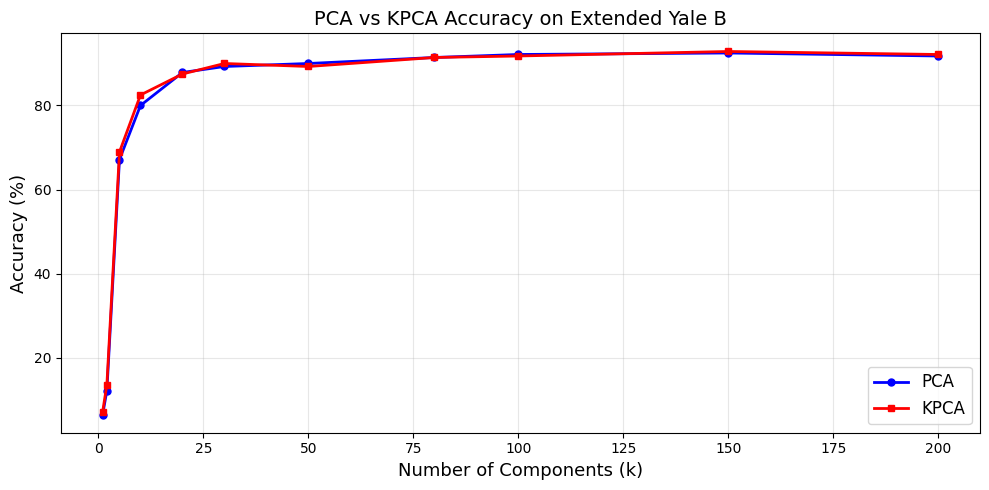


Best PCA:  92.50% at k=150
Best KPCA: 92.86% at k=150


In [6]:
sigma = auto_select_sigma(X_train, multiplier=5)
print(f"Auto-selected sigma = {sigma:.2f}")

k_list = [1, 2, 5, 10, 20, 30, 50, 80, 100, 150, 200]
pca_accs = []
kpca_accs = []

for k in k_list:
    p = pca_classify(X_train, y_train, X_test, y_test, k)
    kp = kpca_classify(X_train, y_train, X_test, y_test, k, sigma)
    pca_accs.append(p)
    kpca_accs.append(kp)
    print(f"k={k:>3d}  |  PCA: {p:6.2f}%  |  KPCA: {kp:6.2f}%  |  diff: {kp-p:+.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(k_list, pca_accs, 'b-o', markersize=5, linewidth=2, label='PCA')
plt.plot(k_list, kpca_accs, 'r-s', markersize=5, linewidth=2, label='KPCA')
plt.xlabel("Number of Components (k)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title(f"PCA vs KPCA Accuracy on Extended Yale B", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest PCA:  {max(pca_accs):.2f}% at k={k_list[np.argmax(pca_accs)]}")
print(f"Best KPCA: {max(kpca_accs):.2f}% at k={k_list[np.argmax(kpca_accs)]}")


### Effect of Training Size

We vary the number of training images per subject from 5 to 80 and compare the best achievable accuracy for each method.

n_train=  5 | sigma=   34173 | PCA: 68.93% | KPCA: 68.93% | diff: +0.00%


n_train= 10 | sigma=   30642 | PCA: 78.93% | KPCA: 78.93% | diff: +0.00%


n_train= 20 | sigma=   27900 | PCA: 82.86% | KPCA: 83.57% | diff: +0.71%


n_train= 30 | sigma=   26062 | PCA: 86.79% | KPCA: 86.07% | diff: -0.71%


n_train= 50 | sigma=   23810 | PCA: 92.14% | KPCA: 92.14% | diff: +0.00%


n_train= 80 | sigma=   21127 | PCA: 97.14% | KPCA: 97.14% | diff: +0.00%


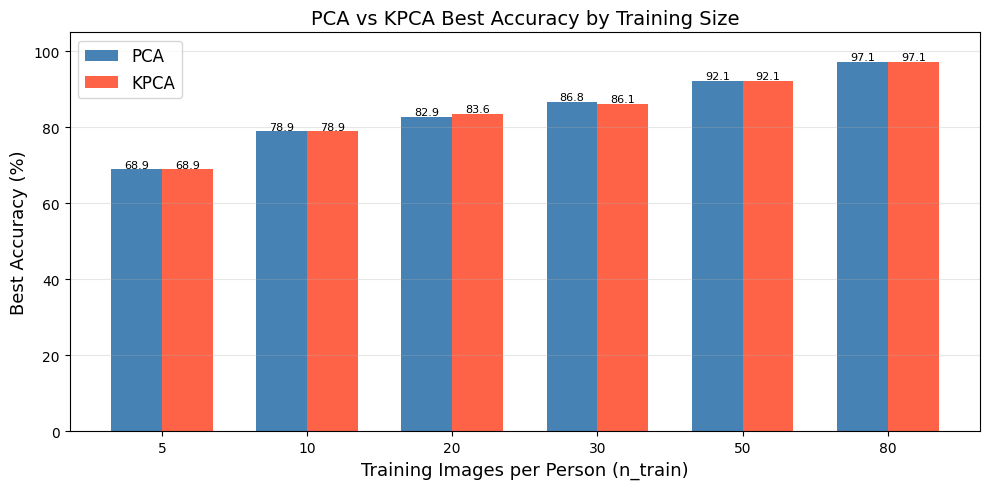

In [7]:
n_train_list = [5, 10, 20, 30, 50, 80]
n_test_fixed = 10
best_pca_list = []
best_kpca_list = []

for n_tr in n_train_list:
    X_tr, y_tr, X_te, y_te = split_data(persons, n_tr, n_test_fixed)
    sig = auto_select_sigma(X_tr, multiplier=5)

    best_p, best_kp = 0, 0
    for k in [5, 10, 20, 50, 100, min(200, n_tr * len(persons) - 1)]:
        p = pca_classify(X_tr, y_tr, X_te, y_te, k)
        kp = kpca_classify(X_tr, y_tr, X_te, y_te, k, sig)
        if p > best_p: best_p = p
        if kp > best_kp: best_kp = kp

    best_pca_list.append(best_p)
    best_kpca_list.append(best_kp)
    print(f"n_train={n_tr:>3d} | sigma={sig:>8.0f} | PCA: {best_p:.2f}% | KPCA: {best_kp:.2f}% | diff: {best_kp-best_p:+.2f}%")

plt.figure(figsize=(10, 5))
x = np.arange(len(n_train_list))
width = 0.35
bars1 = plt.bar(x - width/2, best_pca_list, width, label='PCA', color='steelblue')
bars2 = plt.bar(x + width/2, best_kpca_list, width, label='KPCA', color='tomato')
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}', ha='center', fontsize=8)
plt.xticks(x, [str(n) for n in n_train_list])
plt.xlabel("Training Images per Person (n_train)", fontsize=13)
plt.ylabel("Best Accuracy (%)", fontsize=13)
plt.title("PCA vs KPCA Best Accuracy by Training Size", fontsize=14)
plt.legend(fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Analysis

Both datasets use the 5x auto-sigma rule. With $\sigma$ this large the Gaussian kernel sits in a near-linear regime — for a nearest-neighbour pair $K(d_{NN}) \approx 0.98$ — so KPCA stays essentially on par with PCA. On Extended Yale B this large-$\sigma$ effect is compounded by the very high dimension-to-sample ratio, which already makes the data near-linearly separable.

To make the kernel's regime visible, we plot the kernel matrix at $\sigma = 1\times, 5\times, 10\times$ the mean nearest-neighbour distance: as the multiplier grows the off-diagonal contrast collapses and the kernel approaches a linear one — the regime in which KPCA reduces to PCA.

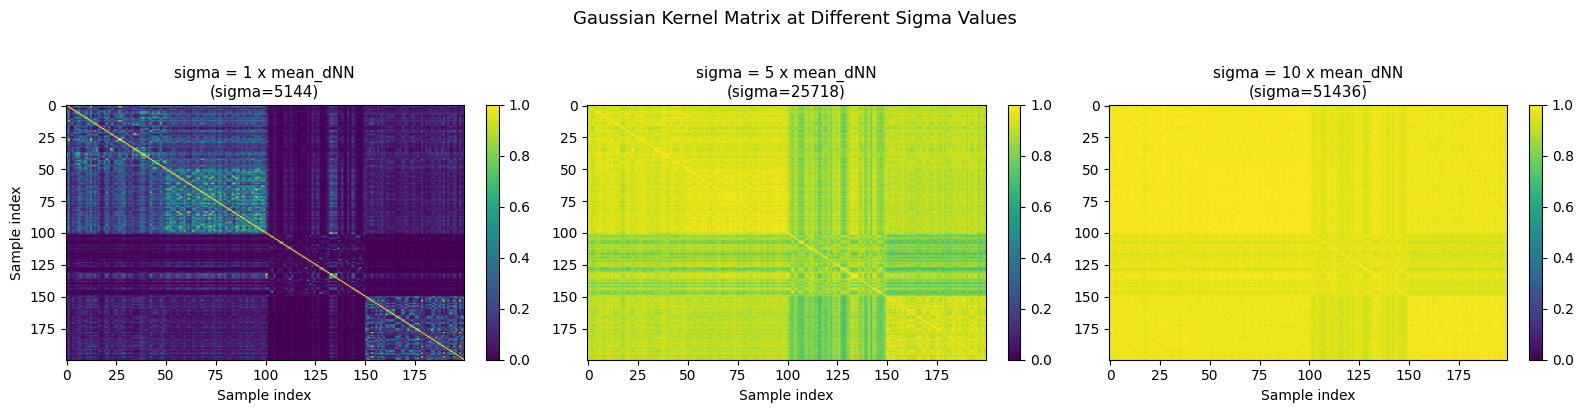

Feature dimension:     32256
Training samples:      1400
Dimension/Sample ratio: 23.0:1
Mean d_NN:             5144
Auto-sigma (5x):       25718

With sigma this large, exp(-d²/2σ²) ≈ 1 - d²/2σ² — that's a linear function.
The Gaussian kernel is barely doing anything nonlinear.
KPCA is essentially just PCA with extra steps.

For KPCA to actually help, you'd need:
  1. Much lower-dimensional features (not 32256d)
  2. Data with genuine nonlinear structure
  3. A smaller sigma that captures local geometry


In [8]:
# Kernel matrix visualization at different sigma values
D = cdist(X_train[:200], X_train[:200], metric='euclidean')  # subset for visualization
np.fill_diagonal(D, np.inf)
mean_dnn = np.mean(np.min(D, axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mult in zip(axes, [1, 5, 10]):
    sig = mult * mean_dnn
    K = np.exp(-D**2 / (2 * sig**2))
    np.fill_diagonal(K, 1)
    im = ax.imshow(K, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f"sigma = {mult} x mean_dNN\n(sigma={sig:.0f})", fontsize=11)
    ax.set_xlabel("Sample index")
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[0].set_ylabel("Sample index")
fig.suptitle("Gaussian Kernel Matrix at Different Sigma Values", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Dataset statistics
print(f"Feature dimension:     {X_train.shape[1]}")
print(f"Training samples:      {X_train.shape[0]}")
print(f"Dimension/Sample ratio: {X_train.shape[1] / X_train.shape[0]:.1f}:1")
print(f"Mean d_NN:             {mean_dnn:.0f}")
print(f"Auto-sigma (5x):       {5 * mean_dnn:.0f}")
print(f"\nWith sigma this large, exp(-d²/2σ²) ≈ 1 - d²/2σ² — that's a linear function.")
print(f"The Gaussian kernel is barely doing anything nonlinear.")
print(f"KPCA is essentially just PCA with extra steps.")
print(f"\nFor KPCA to actually help, you'd need:")
print(f"  1. Much lower-dimensional features (not {X_train.shape[1]}d)")
print(f"  2. Data with genuine nonlinear structure")
print(f"  3. A smaller sigma that captures local geometry")


### Summary

In [ ]:
# Final comparison table (Extended Yale B)
print("=" * 65)
print(f"{'n_train':>8} {'PCA (best)':>12} {'KPCA (best)':>13} {'Difference':>12} {'Winner':>8}")
print("-" * 65)
for i, n_tr in enumerate(n_train_list):
    p, kp = best_pca_list[i], best_kpca_list[i]
    diff = kp - p
    winner = "KPCA" if diff > 0.01 else ("PCA" if diff < -0.01 else "TIE")
    print(f"{n_tr:>8d} {p:>11.2f}% {kp:>12.2f}% {diff:>+11.2f}% {winner:>8}")
print("-" * 65)

print()
print("Findings (5x auto-sigma rule on both datasets):")
print("  Yale Faces:       PCA and KPCA are on par (best 86.67% at n_train=5).")
print(f"  Extended Yale B:  PCA and KPCA are equivalent across training sizes.")
print(f"                    The high D/N ratio ({X_train.shape[1]}/{X_train.shape[0]}) plus the large")
print(f"                    auto-sigma push the Gaussian kernel into a near-linear regime.")
